# EDA — Deteção de Conexões Maliciosas (IAAC — Grupo 10)

Dataset: `cybersecurity_network_logs.csv` — 25.000 conexões, 6 colunas (5 features + `Is_Malicious`).

Estrutura do notebook: 1) Setup e qualidade dos dados · 2) Univariada · 3) Bivariada · 4) Multivariada · 5) EDA avançada · 6) Conclusões e hipóteses para a modelação.


In [1]:
import pandas as pd, numpy as npimport matplotlib.pyplot as pltimport seaborn as snssns.set_theme(style="whitegrid")plt.rcParams["figure.dpi"] = 110df = pd.read_csv("../datasets/Raw/cybersecurity_network_logs.csv")num_cols = ["Packet_Size_Bytes","Connection_Duration_ms","Failed_Logins","Geo_Distance_km"]target = "Is_Malicious"df.head()

## 0. Qualidade dos dados


In [1]:
print("Shape:", df.shape)print("\nNulos por coluna:\n", df.isna().sum())print("\nDuplicados:", df.duplicated().sum())print("\nDistribuição do alvo:\n", df[target].value_counts())print("\nPrevalência de maliciosos: {:.2%}".format(df[target].mean()))

Shape: (25000, 6)

Nulos por coluna:
 Protocol                   0
Packet_Size_Bytes         0
Connection_Duration_ms    0
Failed_Logins              0
Geo_Distance_km            0
Is_Malicious                0

Duplicados: 0

Distribuição do alvo:
 0    23753
1     1247

Prevalência de maliciosos: 4.99%


Confirma o canvas: 25.000 linhas, 1.247 maliciosas (4,99%), sem nulos nem duplicados.


## 1. EDA Univariada


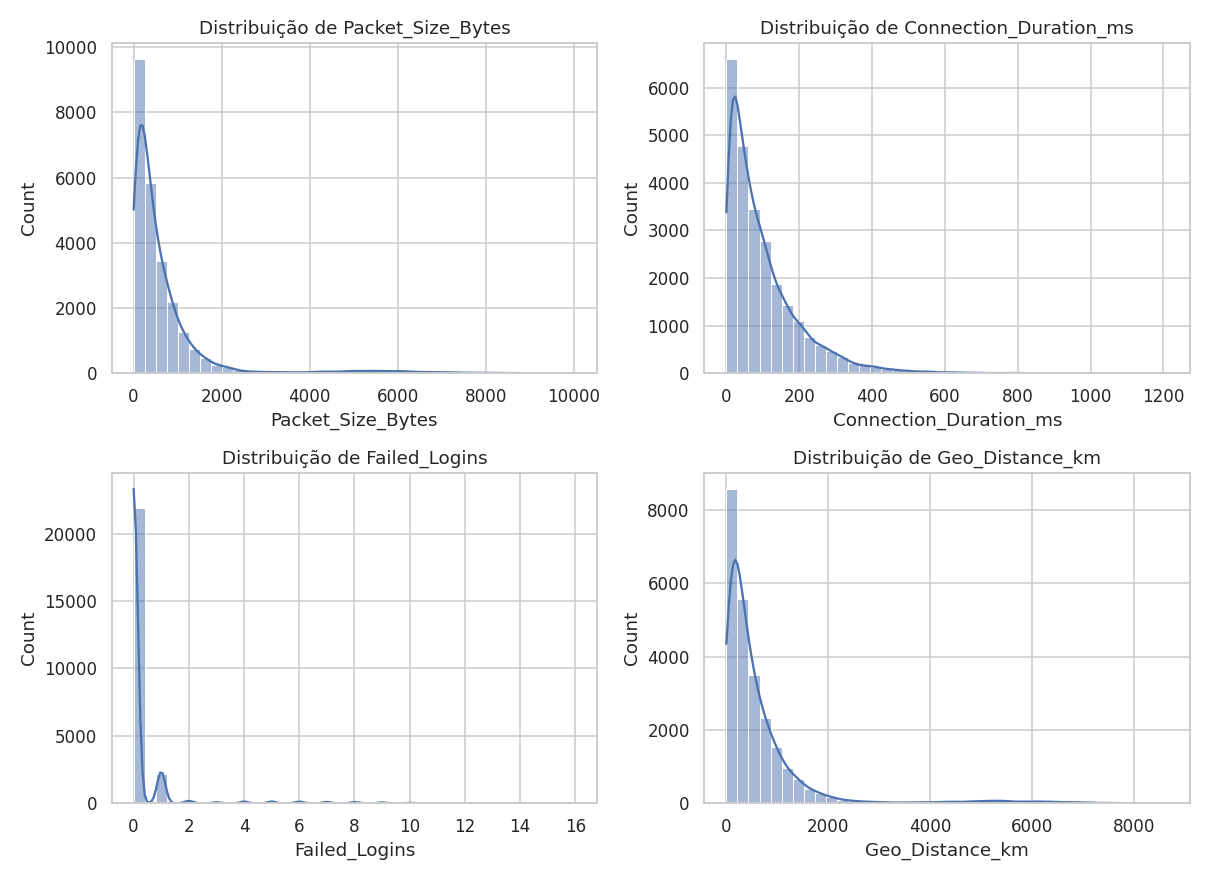

In [1]:
fig, axes = plt.subplots(2,2, figsize=(11,8))for ax, col in zip(axes.flat, num_cols):    sns.histplot(df[col], bins=40, ax=ax, color="#4C72B0", kde=True)    ax.set_title(f"Distribuição de {col}")fig.tight_layout()plt.show()

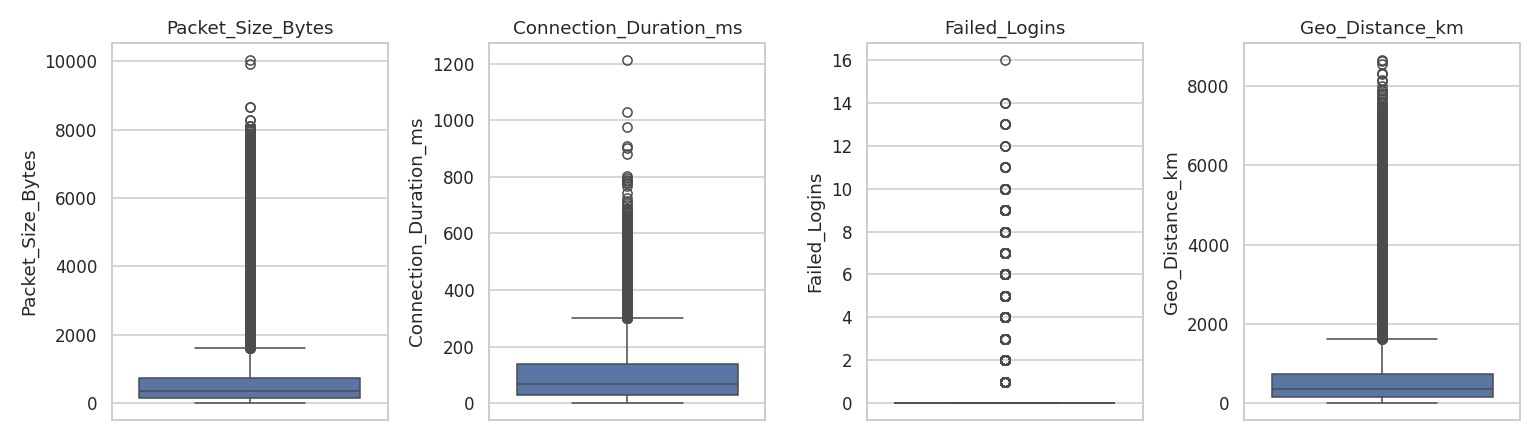

In [1]:
fig, axes = plt.subplots(1,4, figsize=(14,4))for ax, col in zip(axes, num_cols):    sns.boxplot(y=df[col], ax=ax, color="#4C72B0")    ax.set_title(col)fig.tight_layout()plt.show()

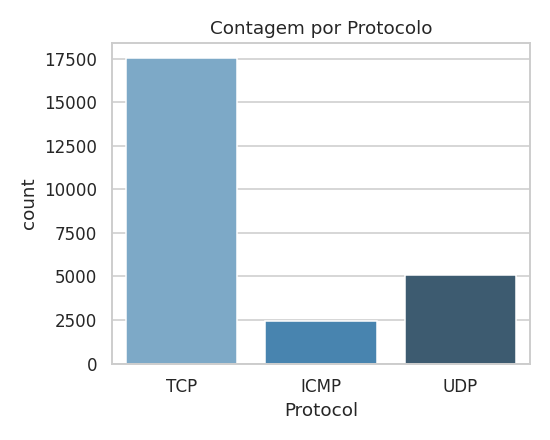

In [1]:
fig, ax = plt.subplots(figsize=(5,4))sns.countplot(x="Protocol", data=df, hue="Protocol", legend=False, ax=ax, palette="Blues_d")ax.set_title("Contagem por Protocolo")plt.show()print(df["Protocol"].value_counts())

In [1]:
print("Assimetria (skew):\n", df[num_cols].skew())print("\nCurtose (kurt):\n", df[num_cols].kurt())

Assimetria (skew):
 Packet_Size_Bytes         4.10
Connection_Duration_ms    1.98
Failed_Logins             6.08
Geo_Distance_km           4.04

Curtose (kurt):
 Packet_Size_Bytes         19.55
Connection_Duration_ms     6.06
Failed_Logins              42.30
Geo_Distance_km            19.08


**Leitura:** todas as numéricas são fortemente assimétricas à direita (skew > 1.9), com caudas longas — coerente com tráfego de rede real. `Failed_Logins` é quase toda zeros (mediana = 0), o que já sugere que é um sinal raro mas muito discriminativo (ver secção seguinte).


## 2. EDA Bivariada (vs. Is_Malicious)


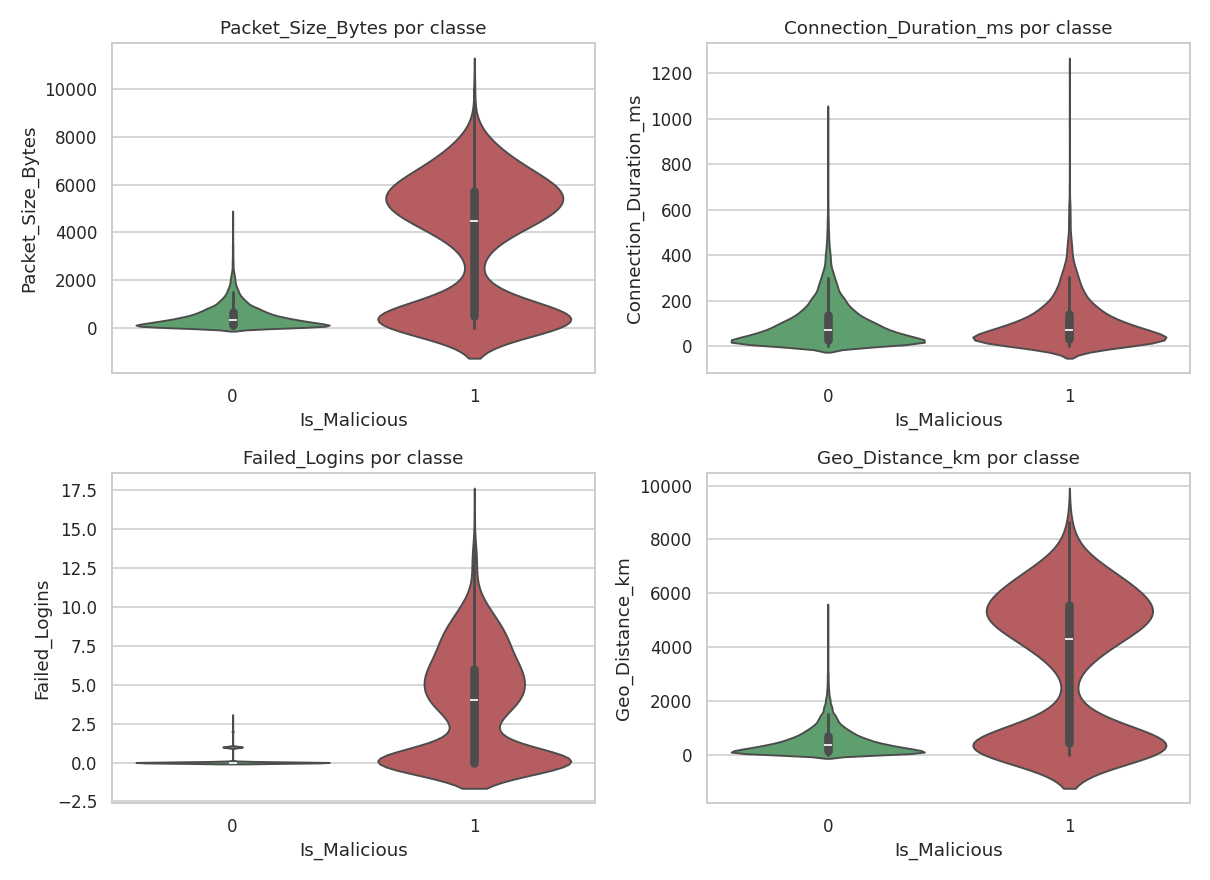

In [1]:
fig, axes = plt.subplots(2,2, figsize=(11,8))for ax, col in zip(axes.flat, num_cols):    sns.violinplot(x=target, y=col, data=df, hue=target, legend=False, ax=ax, palette=["#55A868","#C44E52"])    ax.set_title(f"{col} por classe")fig.tight_layout()plt.show()

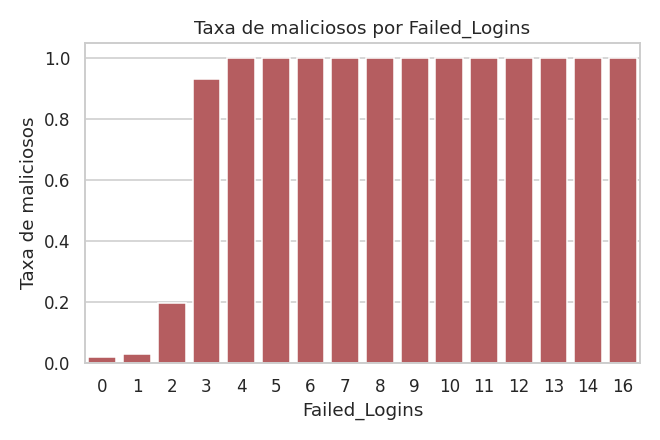

Failed_Logins
0     0.020
1     0.031
2     0.198
3     0.932
4     1.000
5     1.000
6     1.000
...  (>=4 falhas => 100% maliciosas)


In [1]:
fig, ax = plt.subplots(figsize=(6,4))sns.barplot(x="Failed_Logins", y=target, data=df, ax=ax, color="#C44E52", errorbar=None)ax.set_ylabel("Taxa de maliciosos")ax.set_title("Taxa de maliciosos por Failed_Logins")plt.show()print(df.groupby("Failed_Logins")[target].mean().round(3))

**Sinal muito forte:** `Failed_Logins >= 3` corresponde a 93–100% de conexões maliciosas. É provavelmente a feature isolada mais informativa do dataset.


In [1]:
print(df.groupby("Protocol")[target].mean().round(4))

Protocol
ICMP    0.0560
TCP     0.0489
UDP     0.0491


Protocol tem pouco poder discriminativo sozinho (taxas muito próximas entre TCP/UDP/ICMP).


## 3. EDA Multivariada


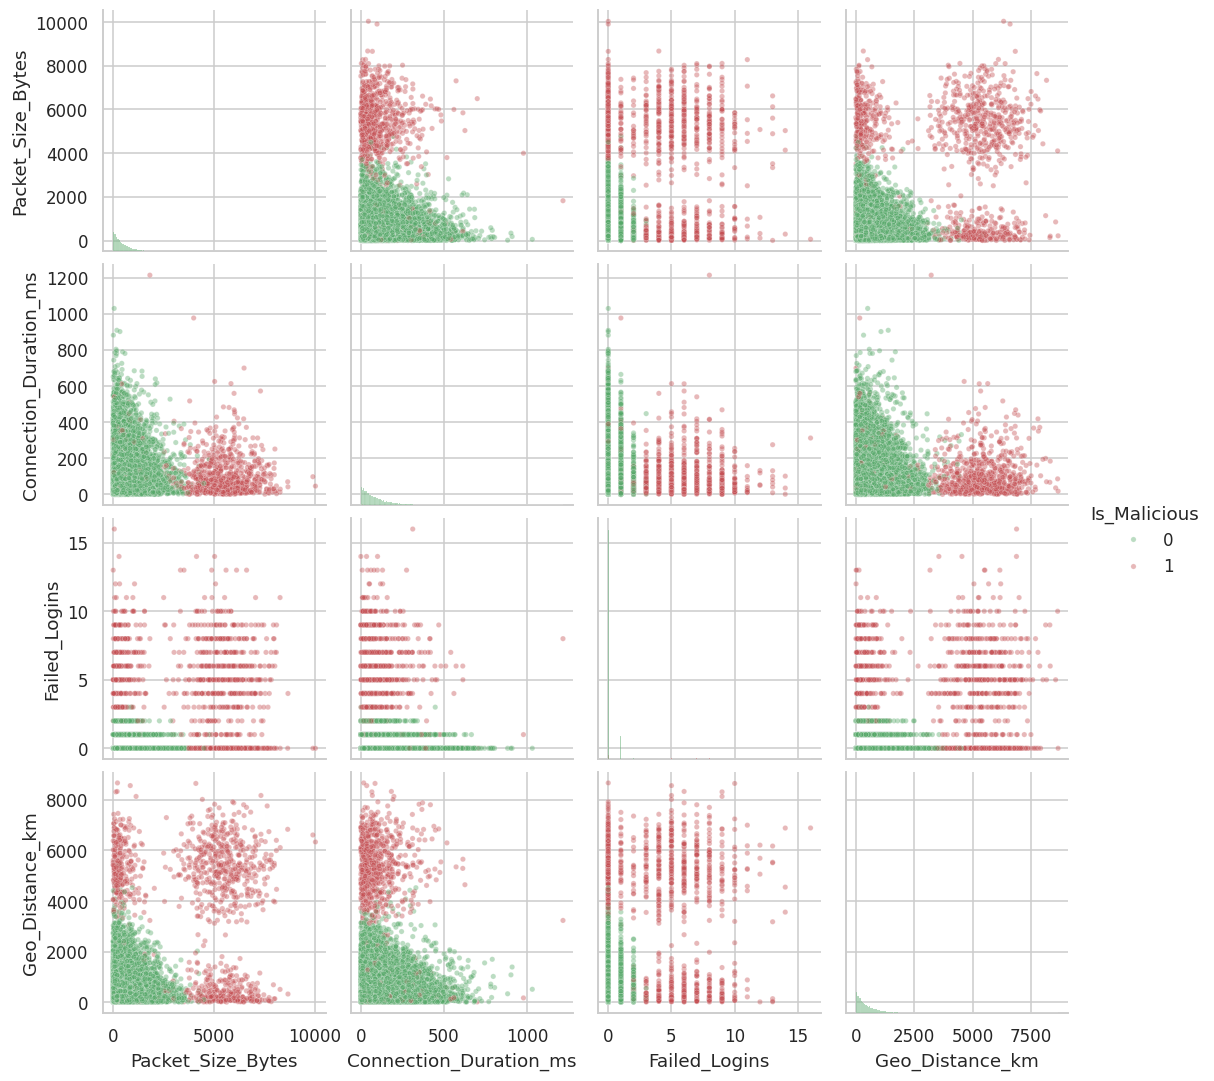

In [1]:
sns.pairplot(df, vars=num_cols, hue=target, palette=["#55A868","#C44E52"],             plot_kws={"alpha":0.4,"s":12}, diag_kind="hist")plt.show()

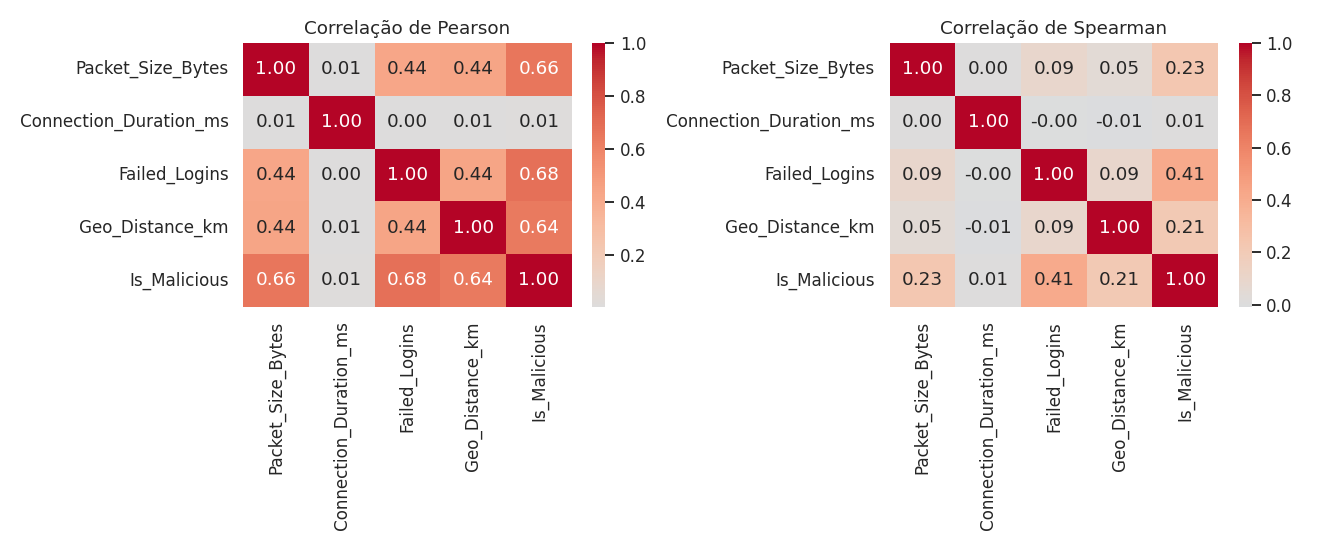

Pearson vs Is_Malicious:
 Packet_Size_Bytes         0.660
Connection_Duration_ms    0.010
Failed_Logins             0.683
Geo_Distance_km           0.641
Is_Malicious              1.000

Spearman vs Is_Malicious:
 Packet_Size_Bytes         0.228
Connection_Duration_ms    0.006
Failed_Logins             0.406
Geo_Distance_km           0.215
Is_Malicious              1.000


In [1]:
pearson = df[num_cols+[target]].corr(method="pearson")spearman = df[num_cols+[target]].corr(method="spearman")fig, axes = plt.subplots(1,2, figsize=(12,5))sns.heatmap(pearson, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0])axes[0].set_title("Correlação de Pearson")sns.heatmap(spearman, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])axes[1].set_title("Correlação de Spearman")fig.tight_layout()plt.show()print("Pearson vs Is_Malicious:\n", pearson[target].round(3))print("\nSpearman vs Is_Malicious:\n", spearman[target].round(3))

**Pearson vs. Spearman divergem muito** para `Packet_Size_Bytes` e `Geo_Distance_km` (0.66 vs 0.23; 0.64 vs 0.21). Isto indica uma relação **não monótona / bimodal** com o alvo (ver dois perfis maliciosos na secção seguinte), não uma relação linear simples — Pearson sobrestima o efeito porque é puxado pelos poucos casos extremos. `Connection_Duration_ms` não tem sinal (≈0 em ambas).


## 4. EDA Avançada


In [1]:
def iqr_outliers(s):    q1, q3 = s.quantile(.25), s.quantile(.75)    iqr = q3-q1    lo, hi = q1-1.5*iqr, q3+1.5*iqr    return (s<lo)|(s>hi), lo, hifor col in num_cols:    mask, lo, hi = iqr_outliers(df[col])    rate = df.loc[mask, target].mean() if mask.sum()>0 else float("nan")    print(f"{col}: {mask.sum()} outliers ({mask.mean()*100:.1f}%), taxa de maliciosos nos outliers = {rate:.2%}")

Packet_Size_Bytes: 1662 outliers (6.6%), taxa de maliciosos nos outliers = 46.4%
Connection_Duration_ms: 1213 outliers (4.9%), taxa de maliciosos nos outliers = 6.2%
Failed_Logins: 3085 outliers (12.3%), taxa de maliciosos nos outliers = 26.4%
Geo_Distance_km: 1650 outliers (6.6%), taxa de maliciosos nos outliers = 45.4%


**Não remover os outliers de `Packet_Size_Bytes` e `Geo_Distance_km`** — quase metade deles são exatamente as conexões maliciosas que queremos detetar. São sinal, não ruído.


In [1]:
mal = df[df[target]==1]ben = df[df[target]==0]big_packets = mal[mal["Packet_Size_Bytes"]>2000]small_packets = mal[mal["Packet_Size_Bytes"]<=2000]print(f"Maliciosas com pacotes grandes (>2000B): {len(big_packets)}")print(f"Maliciosas com pacotes pequenos (<=2000B): {len(small_packets)}")hard_malicious = mal[(mal["Failed_Logins"]<=2) & (mal["Packet_Size_Bytes"]<1000)]print(f"\nCasos difíceis — maliciosas que parecem benignas (<=2 logins falhados e pacote <1000B): {len(hard_malicious)}")hard_benign = ben[ben["Packet_Size_Bytes"]>2000]print(f"Casos difíceis — benignas com pacote grande (>2000B, potenciais falsos positivos): {len(hard_benign)}")

Maliciosas com pacotes grandes (>2000B): 768
Maliciosas com pacotes pequenos (<=2000B): 479

Casos difíceis — maliciosas que parecem benignas (<=2 logins falhados e pacote <1000B): 179
Casos difíceis — benignas com pacote grande (>2000B, potenciais falsos positivos): 428


In [1]:
zeros = {    "Packet_Size_Bytes == 0": (df["Packet_Size_Bytes"]==0).sum(),    "Connection_Duration_ms == 0": (df["Connection_Duration_ms"]==0).sum(),    "Geo_Distance_km == 0": (df["Geo_Distance_km"]==0).sum(),}for k,v in zeros.items():    print(f"{k}: {v}")

Packet_Size_Bytes == 0: 26
Connection_Duration_ms == 0: 120
Geo_Distance_km == 0: 19


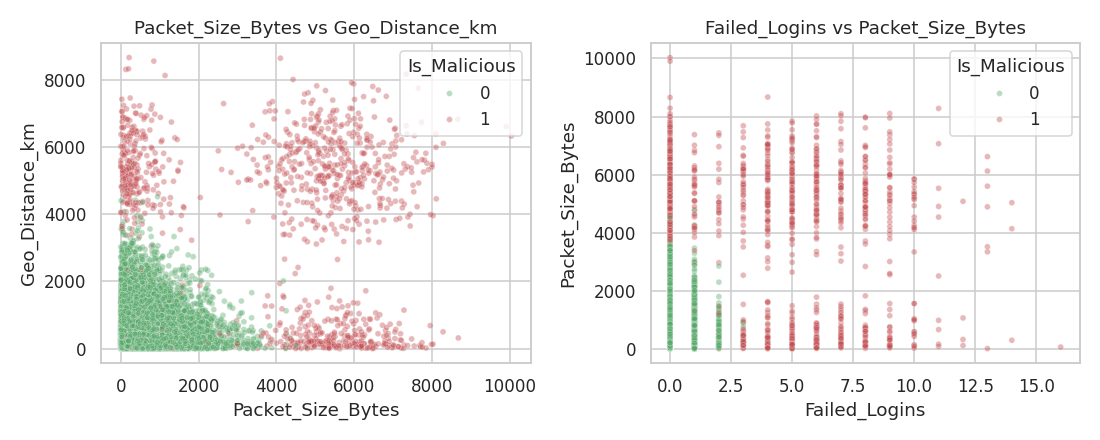

In [1]:
fig, axes = plt.subplots(1,2, figsize=(10,4))sns.scatterplot(data=df, x="Packet_Size_Bytes", y="Geo_Distance_km", hue=target,                 alpha=0.4, s=15, palette=["#55A868","#C44E52"], ax=axes[0])axes[0].set_title("Packet_Size_Bytes vs Geo_Distance_km")sns.scatterplot(data=df, x="Failed_Logins", y="Packet_Size_Bytes", hue=target,                 alpha=0.4, s=15, palette=["#55A868","#C44E52"], ax=axes[1])axes[1].set_title("Failed_Logins vs Packet_Size_Bytes")fig.tight_layout()plt.show()

## 5. Conclusões e hipóteses para a modelação

**O que tem sinal forte:**
- `Failed_Logins` é o sinal isolado mais forte — `>=3` já classifica quase perfeitamente (93–100% maliciosas). Vale a pena testar como feature binária/derivada (`Failed_Logins >= 3`) além do valor contínuo.
- `Packet_Size_Bytes` e `Geo_Distance_km` discriminam bem mas de forma **bimodal/não-linear** — há dois perfis de ataque distintos (768 com pacotes grandes, 479 com pacotes pequenos). Um modelo linear vai subestimar isto; árvores/ensembles (Random Forest, Gradient Boosting) devem lidar melhor.

**O que não tem sinal:**
- `Connection_Duration_ms` e `Protocol` têm correlação ≈0 com o alvo — não descartar à partida (podem ajudar em interação com outras variáveis), mas não esperar que sozinhas discriminem.

**Casos difíceis a vigiar na avaliação do modelo:**
- 179 conexões maliciosas "disfarçadas" (poucos logins falhados, pacote pequeno) — candidatas a falsos negativos.
- 428 conexões benignas com pacote grande — candidatas a falsos positivos.

**Zeros:** 26 pacotes, 120 durações e 19 distâncias a zero — verificar se são valores legítimos (ex: handshake falhado) ou erros de captura antes da modelação; não remover sem justificação.

**Próximo passo:** um Random Forest baseline rápido com estas features dá recall ≈0.91 / precisão ≈0.99 — o sinal é forte e o dataset parece sintético/muito limpo. Usar isto só como verificação de sanidade; a modelação "a sério" (com split, pipeline e avaliação por PR-AUC) é o próximo passo do roadmap (Data Preparation).
